In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

In [9]:
df = pd.read_csv('C:\\Users\\HP\\Documents\\EDWIN\\AUTOCAD\\PHYTON\\Proyecto 1\\AEP_hourly.csv')
df.head(10)

,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0
5,2004-12-31 06:00:00,13038.0
6,2004-12-31 07:00:00,13692.0
7,2004-12-31 08:00:00,14297.0
8,2004-12-31 09:00:00,14719.0
9,2004-12-31 10:00:00,14941.0


In [11]:
print("Forma del dataset:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos:")
print(df.isnull().sum())
print("\nEstadísticas básicas:")
df.describe()

Forma del dataset: (121273, 2)

Tipos de datos:
Datetime     object
AEP_MW      float64
dtype: object

Valores nulos:
Datetime    0
AEP_MW      0
dtype: int64

Estadísticas básicas:


,AEP_MW
count,121273.000000
mean,15499.513717
std,2591.399065
min,9581.000000
25%,13630.000000
50%,15310.000000
75%,17200.000000
max,25695.000000


In [13]:
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.sort_values('Datetime')
df = df.set_index('Datetime')
df.head()

,AEP_MW
Datetime,
2004-10-01 01:00:00,12379.0
2004-10-01 02:00:00,11935.0
2004-10-01 03:00:00,11692.0
2004-10-01 04:00:00,11597.0
2004-10-01 05:00:00,11681.0


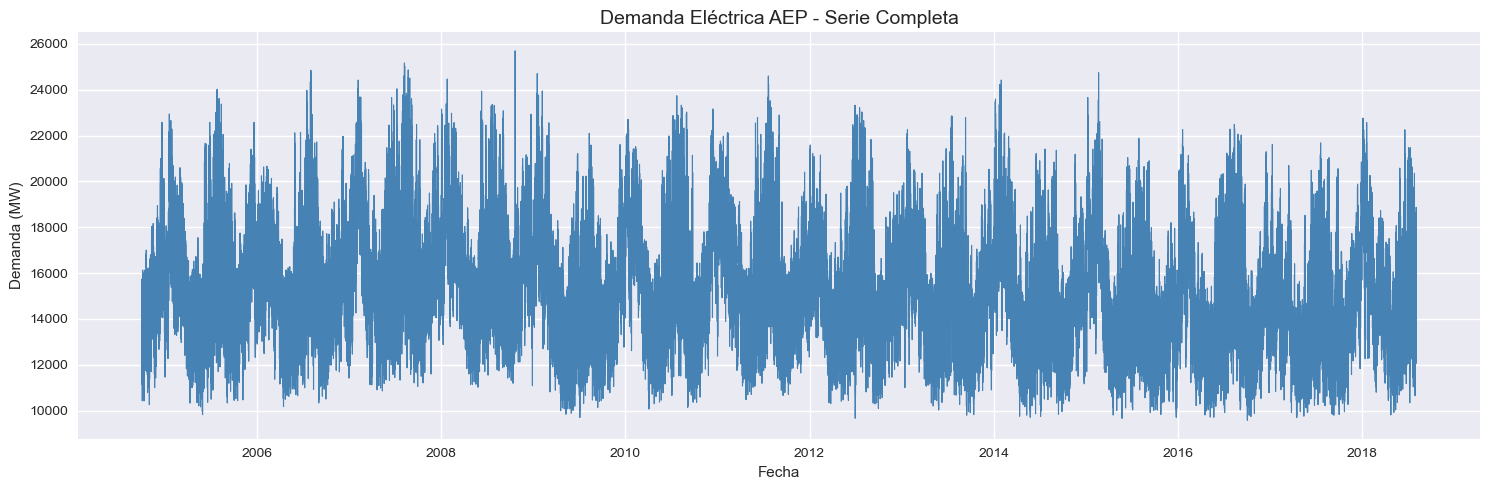

In [15]:
plt.figure(figsize=(15, 5))
plt.plot(df['AEP_MW'], color='steelblue', linewidth=0.8)
plt.title('Demanda Eléctrica AEP - Serie Completa', fontsize=14)
plt.xlabel('Fecha')
plt.ylabel('Demanda (MW)')
plt.tight_layout()
plt.show()

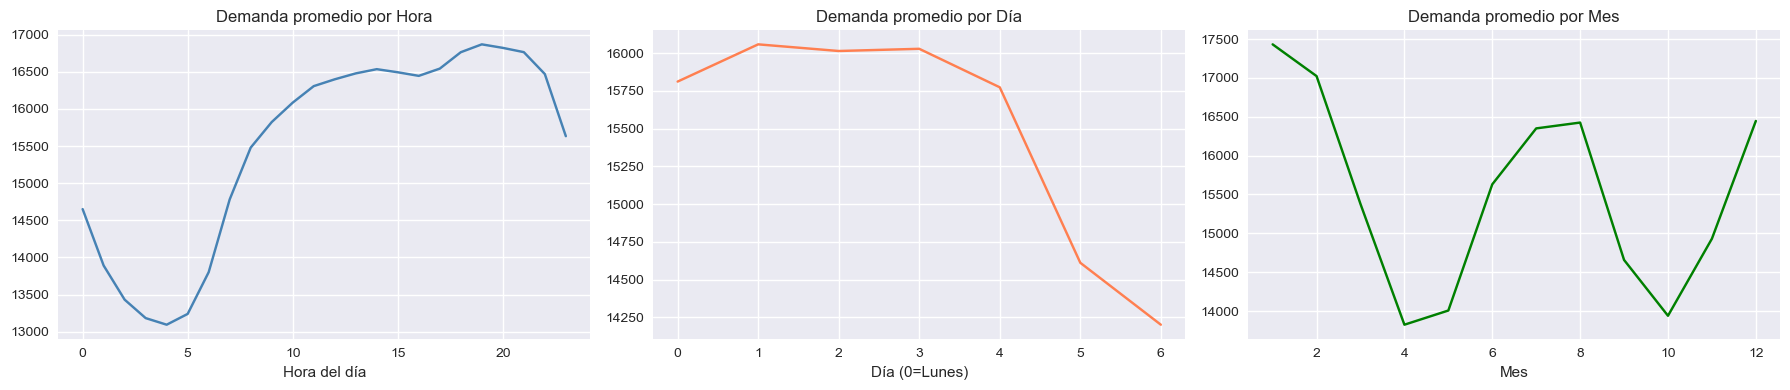

In [17]:
df['hora'] = df.index.hour
df['dia_semana'] = df.index.dayofweek
df['mes'] = df.index.month
df['año'] = df.index.year

# Demanda promedio por hora
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

df.groupby('hora')['AEP_MW'].mean().plot(ax=axes[0], color='steelblue')
axes[0].set_title('Demanda promedio por Hora')
axes[0].set_xlabel('Hora del día')

df.groupby('dia_semana')['AEP_MW'].mean().plot(ax=axes[1], color='coral')
axes[1].set_title('Demanda promedio por Día')
axes[1].set_xlabel('Día (0=Lunes)')

df.groupby('mes')['AEP_MW'].mean().plot(ax=axes[2], color='green')
axes[2].set_title('Demanda promedio por Mes')
axes[2].set_xlabel('Mes')

plt.tight_layout()
plt.show()

In [19]:
Q1 = df['AEP_MW'].quantile(0.25)
Q3 = df['AEP_MW'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['AEP_MW'] < Q1 - 1.5*IQR) | (df['AEP_MW'] > Q3 + 1.5*IQR)]
print(f"Valores atípicos encontrados: {len(outliers)}")
print(f"Representan el {len(outliers)/len(df)*100:.2f}% del dataset")

Valores atípicos encontrados: 667
Representan el 0.55% del dataset
